In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
file_path = "../data/raw/online_retail_II.xlsx"

# Load the two sheets
df_2009 = pd.read_excel(
    file_path,
    sheet_name="Year 2009-2010"
)

df_2010 = pd.read_excel(
    file_path,
    sheet_name="Year 2010-2011"
)

print("2009-2010 shape:", df_2009.shape)
print("2010-2011 shape:", df_2010.shape)

KeyboardInterrupt: 

In [5]:
import pandas as pd

file_path = "../data/raw/online_retail_II.xlsx"

print("Opening Excel file...")

excel_file = pd.ExcelFile(file_path, engine="openpyxl")

print("Available sheets:")
print(excel_file.sheet_names)

Opening Excel file...
Available sheets:
['Year 2009-2010', 'Year 2010-2011']


In [6]:
print("Loading 2009-2010 data...")

df_2009 = pd.read_excel(
    excel_file,
    sheet_name="Year 2009-2010"
)

print("2009-2010 loaded!")
print("Rows:", len(df_2009))
print("Columns:", len(df_2009.columns))

Loading 2009-2010 data...
2009-2010 loaded!
Rows: 525461
Columns: 8


In [7]:
print("Loading 2010-2011 data...")

df_2010 = pd.read_excel(
    excel_file,
    sheet_name="Year 2010-2011"
)

print("2010-2011 loaded!")
print("Rows:", len(df_2010))
print("Columns:", len(df_2010.columns))

Loading 2010-2011 data...
2010-2011 loaded!
Rows: 541910
Columns: 8


In [8]:
print("2009-2010:", df_2009.shape)
print("2010-2011:", df_2010.shape)

2009-2010: (525461, 8)
2010-2011: (541910, 8)


In [9]:
df = pd.concat(
    [df_2009, df_2010],
    ignore_index=True
)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (1067371, 8)


In [10]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [11]:
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [12]:
df.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
23709,491226,72753D,S/3 FLWR FAIRY SUMMER CANDLES,8,2009-12-10 14:44:00,2.10,15157.0,United Kingdom
211180,509850,POST,POSTAGE,7,2010-05-26 09:00:00,18.00,12656.0,France
972204,574918,85136A,YELLOW SHARK HELICOPTER,1,2011-11-07 16:31:00,7.95,NaN,France
523214,538035,22581,WOOD STOCKING CHRISTMAS SCANDISPOT,2,2010-12-09 13:03:00,0.85,16065.0,United Kingdom
447503,532021,22457,NATURAL SLATE HEART CHALKBOARD,5,2010-11-10 13:09:00,2.95,16208.0,United Kingdom


In [13]:
df.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country']

In [14]:
missing = df.isnull().sum()

print("Missing values:")
print(missing)

Missing values:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [15]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

print("Missing percentage:")
print(missing_percentage.sort_values(ascending=False))

Missing percentage:
Customer ID    22.77
Description     0.41
StockCode       0.00
Invoice         0.00
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Country         0.00
dtype: float64


In [16]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 34335


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


In [18]:
df[["Quantity", "Price"]].describe()

,Quantity,Price
count,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00
std,1.727058e+02,1.235531e+02
min,-8.099500e+04,-5.359436e+04
25%,1.000000e+00,1.250000e+00
50%,3.000000e+00,2.100000e+00
75%,1.000000e+01,4.150000e+00
max,8.099500e+04,3.897000e+04


In [19]:
negative_quantity = (df["Quantity"] < 0).sum()

print("Transactions with negative quantity:", negative_quantity)

Transactions with negative quantity: 22950


In [20]:
df["Quantity"].apply(
    lambda x: "Negative" if x < 0 else "Positive"
).value_counts()

Quantity
Positive    1044421
Negative      22950
Name: count, dtype: int64

In [21]:
cancelled_invoices = (
    df["Invoice"]
    .astype(str)
    .str.startswith("C")
    .sum()
)

print("Cancelled transactions:", cancelled_invoices)

Cancelled transactions: 19494


In [22]:
df["Invoice"].astype(str).str.startswith("C").value_counts()

Invoice
False    1047877
True       19494
Name: count, dtype: int64

In [24]:
invalid_price = (df["Price"] <= 0).sum()

print("Transactions with zero/negative price:", invalid_price)

Transactions with zero/negative price: 6207


In [25]:
df[df["Price"] <= 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


In [26]:
print("Earliest transaction:", df["InvoiceDate"].min())
print("Latest transaction:", df["InvoiceDate"].max())

Earliest transaction: 2009-12-01 07:45:00
Latest transaction: 2011-12-09 12:50:00


In [27]:
print("Missing InvoiceDate:", df["InvoiceDate"].isnull().sum())

Missing InvoiceDate: 0


In [28]:
print("Unique customers:", df["Customer ID"].nunique())
print("Missing Customer IDs:", df["Customer ID"].isnull().sum())

Unique customers: 5942
Missing Customer IDs: 243007


In [29]:
print("Unique products:", df["StockCode"].nunique())
print("Unique countries:", df["Country"].nunique())

Unique products: 5305
Unique countries: 43


In [30]:
print(df["Country"].value_counts().head(10))

Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64


In [31]:
df_clean = df.copy()

print("Original rows:", len(df_clean))
print("Original columns:", len(df_clean.columns))

Original rows: 1067371
Original columns: 8


In [32]:
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.replace(" ", "_")
)

df_clean.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer_ID',
 'Country']

In [33]:
df_clean["Invoice"] = df_clean["Invoice"].astype(str)
df_clean["StockCode"] = df_clean["StockCode"].astype(str)
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"], errors="coerce")

In [34]:
df_clean["Customer_ID"] = pd.to_numeric(
    df_clean["Customer_ID"],
    errors="coerce"
)

In [35]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 34335


In [36]:
df_clean = df_clean.drop_duplicates().copy()

print("Rows after removing duplicates:", len(df_clean))

Rows after removing duplicates: 1033036


In [37]:
df_clean["Is_Return"] = (
    df_clean["Invoice"].str.startswith("C") |
    (df_clean["Quantity"] < 0)
)

In [38]:
df_clean["Is_Return"].value_counts()

Is_Return
False    1010539
True       22497
Name: count, dtype: int64

In [39]:
df_clean["Revenue"] = (
    df_clean["Quantity"] * df_clean["Price"]
)

In [40]:
df_clean[
    ["Quantity", "Price", "Revenue", "Is_Return"]
].head(10)

,Quantity,Price,Revenue,Is_Return
0,12,6.95,83.4,False
1,12,6.75,81.0,False
2,12,6.75,81.0,False
3,48,2.10,100.8,False
4,24,1.25,30.0,False
5,24,1.65,39.6,False
6,24,1.25,30.0,False
7,10,5.95,59.5,False
8,12,2.55,30.6,False
9,12,3.75,45.0,False


In [41]:
df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["Month_Name"] = df_clean["InvoiceDate"].dt.month_name()
df_clean["Quarter"] = df_clean["InvoiceDate"].dt.quarter
df_clean["Day_of_Week"] = df_clean["InvoiceDate"].dt.day_name()

In [42]:
df_clean["Month_Start"] = (
    df_clean["InvoiceDate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

In [43]:
df_clean["Customer_Status"] = np.where(
    df_clean["Customer_ID"].isna(),
    "Unknown",
    "Identified"
)

In [44]:
df_clean["Customer_Status"].value_counts()

Customer_Status
Identified    797885
Unknown       235151
Name: count, dtype: int64

In [45]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Is_Return,Revenue,Year,Month,Month_Name,Quarter,Day_of_Week,Month_Start,Customer_Status
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,2009,12,December,4,Tuesday,2009-12-01,Identified
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,December,4,Tuesday,2009-12-01,Identified
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,2009,12,December,4,Tuesday,2009-12-01,Identified
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,2009,12,December,4,Tuesday,2009-12-01,Identified
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,2009,12,December,4,Tuesday,2009-12-01,Identified


In [46]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 1033036 entries, 0 to 1067370
Data columns (total 17 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   Invoice          1033036 non-null  str           
 1   StockCode        1033036 non-null  str           
 2   Description      1028761 non-null  object        
 3   Quantity         1033036 non-null  int64         
 4   InvoiceDate      1033036 non-null  datetime64[us]
 5   Price            1033036 non-null  float64       
 6   Customer_ID      797885 non-null   float64       
 7   Country          1033036 non-null  str           
 8   Is_Return        1033036 non-null  bool          
 9   Revenue          1033036 non-null  float64       
 10  Year             1033036 non-null  int32         
 11  Month            1033036 non-null  int32         
 12  Month_Name       1033036 non-null  str           
 13  Quarter          1033036 non-null  int32         
 14  Day_of_Week      1

In [47]:
df_clean.shape

(1033036, 17)

In [48]:
df_clean[
    [
        "Invoice",
        "StockCode",
        "Quantity",
        "Price",
        "Revenue",
        "Is_Return",
        "Year",
        "Month",
        "Quarter",
        "Customer_Status"
    ]
].head(10)

,Invoice,StockCode,Quantity,Price,Revenue,Is_Return,Year,Month,Quarter,Customer_Status
0,489434,85048,12,6.95,83.4,False,2009,12,4,Identified
1,489434,79323P,12,6.75,81.0,False,2009,12,4,Identified
2,489434,79323W,12,6.75,81.0,False,2009,12,4,Identified
3,489434,22041,48,2.10,100.8,False,2009,12,4,Identified
4,489434,21232,24,1.25,30.0,False,2009,12,4,Identified
5,489434,22064,24,1.65,39.6,False,2009,12,4,Identified
6,489434,21871,24,1.25,30.0,False,2009,12,4,Identified
7,489434,21523,10,5.95,59.5,False,2009,12,4,Identified
8,489435,22350,12,2.55,30.6,False,2009,12,4,Identified
9,489435,22349,12,3.75,45.0,False,2009,12,4,Identified


In [49]:
cleaned_path = "../data/cleaned/online_retail_cleaned.csv"

df_clean.to_csv(
    cleaned_path,
    index=False
)

print("Cleaned dataset saved successfully!")
print(cleaned_path)

Cleaned dataset saved successfully!
../data/cleaned/online_retail_cleaned.csv


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_clean = pd.read_csv(
    "../data/cleaned/online_retail_cleaned.csv",
    parse_dates=["InvoiceDate", "Month_Start"]
)

print(df_clean.shape)

(1033036, 17)


In [51]:
sales_df = df_clean[
    (df_clean["Is_Return"] == False) &
    (df_clean["Quantity"] > 0) &
    (df_clean["Price"] > 0)
].copy()

print("Sales transactions:", len(sales_df))

Sales transactions: 1007913


In [52]:
returns_df = df_clean[
    df_clean["Is_Return"] == True
].copy()

print("Return transactions:", len(returns_df))

Return transactions: 22497


In [53]:
total_revenue = sales_df["Revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 20476260.448


In [54]:
total_orders = sales_df["Invoice"].nunique()

print("Total Orders:", total_orders)

Total Orders: 40077


In [55]:
total_customers = sales_df["Customer_ID"].nunique()

print("Total Customers:", total_customers)

Total Customers: 5878


In [56]:
total_products = sales_df["StockCode"].nunique()

print("Total Products:", total_products)

Total Products: 4917


In [57]:
total_quantity = sales_df["Quantity"].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 11205148


In [58]:
aov = total_revenue / total_orders

print("Average Order Value:", round(aov, 2))

Average Order Value: 510.92


In [59]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Total Quantity Sold",
        "Average Order Value"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        total_products,
        total_quantity,
        aov
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,2.047626e+07
1,Total Orders,4.007700e+04
2,Total Customers,5.878000e+03
3,Total Products,4.917000e+03
4,Total Quantity Sold,1.120515e+07
5,Average Order Value,5.109230e+02


In [60]:
monthly_revenue = (
    sales_df
    .groupby("Month_Start")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,Month_Start,Revenue
0,2009-12-01,822483.950
1,2010-01-01,651155.112
2,2010-02-01,551504.726
3,2010-03-01,830915.261
4,2010-04-01,678875.252


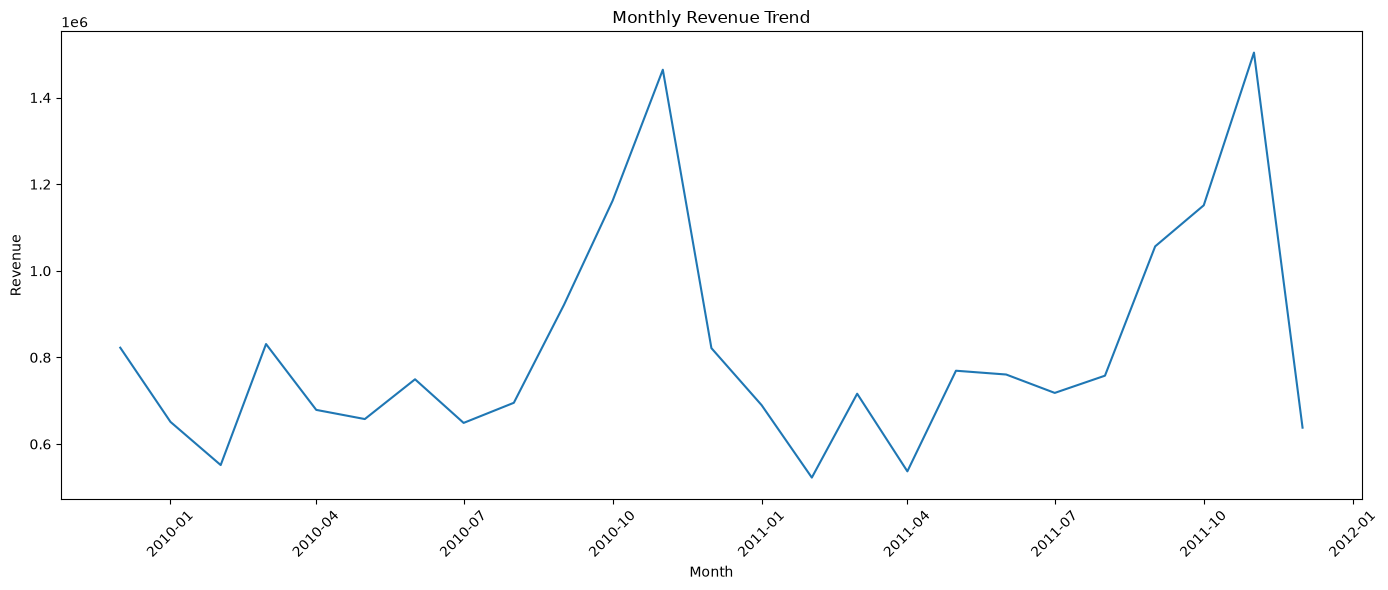

In [61]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["Month_Start"],
    monthly_revenue["Revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
monthly_orders = (
    sales_df
    .groupby("Month_Start")["Invoice"]
    .nunique()
    .reset_index(name="Orders")
)

monthly_orders.head()

,Month_Start,Orders
0,2009-12-01,1682
1,2010-01-01,1105
2,2010-02-01,1201
3,2010-03-01,1681
4,2010-04-01,1462


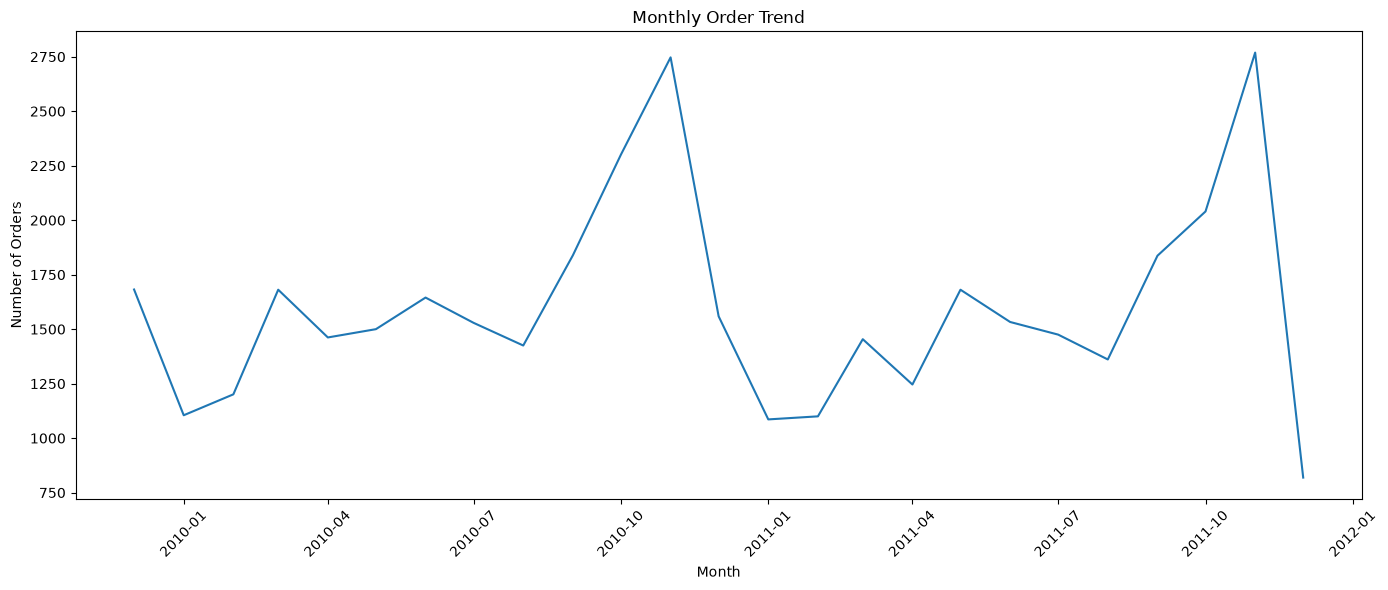

In [63]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_orders["Month_Start"],
    monthly_orders["Orders"]
)

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [64]:
top_products = (
    sales_df
    .groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
Manual                                339241.29
REGENCY CAKESTAND 3 TIER              330590.32
DOTCOM POSTAGE                        309854.11
WHITE HANGING HEART T-LIGHT HOLDER    260990.22
PAPER CRAFT , LITTLE BIRDIE           168469.60
PARTY BUNTING                         148318.28
JUMBO BAG RED RETROSPOT               148073.47
ASSORTED COLOUR BIRD ORNAMENT         129324.49
POSTAGE                               125682.42
PAPER CHAIN KIT 50'S CHRISTMAS        117760.29
Name: Revenue, dtype: float64

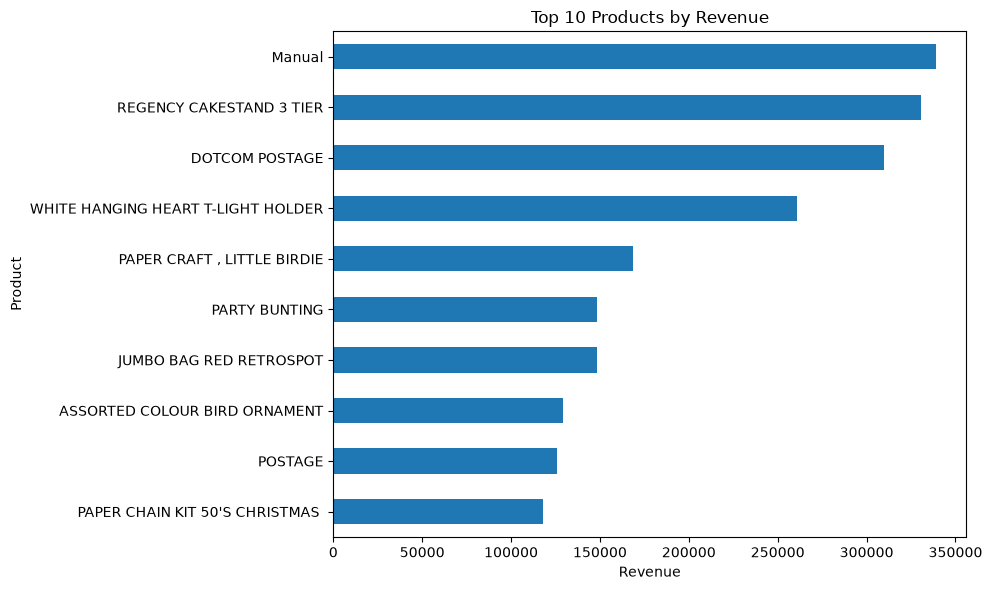

In [65]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [66]:
top_quantity_products = (
    sales_df
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity_products

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     106139
WHITE HANGING HEART T-LIGHT HOLDER     94658
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          80082
MEDIUM CERAMIC TOP STORAGE JAR         78033
JUMBO BAG RED RETROSPOT                77699
BROCADE RING PURSE                     70369
PACK OF 60 PINK PAISLEY CAKE CASES     56061
60 TEATIME FAIRY CAKE CASES            54028
SMALL POPCORN HOLDER                   48561
Name: Quantity, dtype: int64

In [67]:
country_revenue = (
    sales_df
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    1.741020e+07
EIRE              6.587673e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.504561e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.006856e+05
Sweden            9.186982e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64

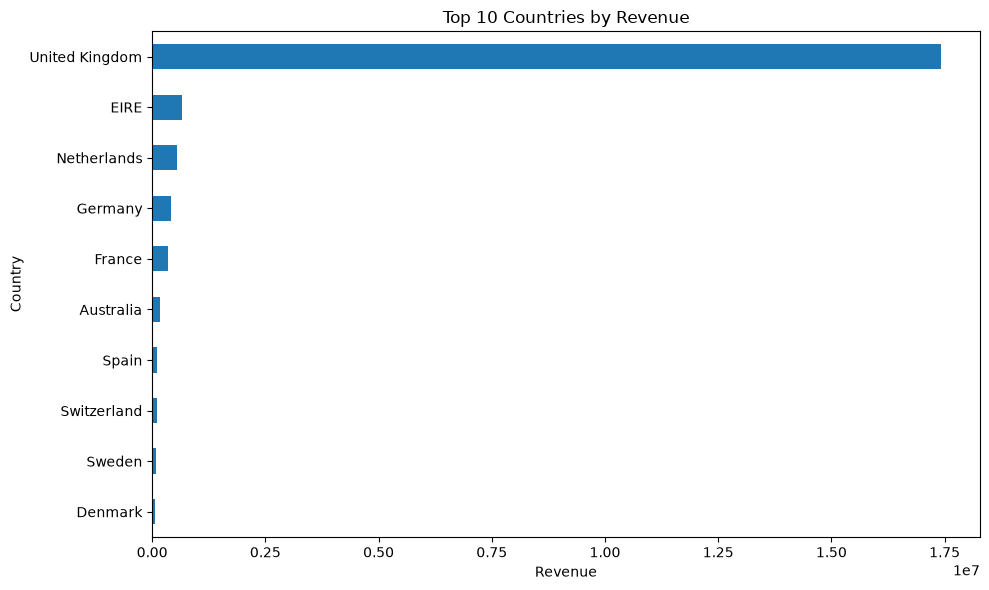

In [68]:
plt.figure(figsize=(10, 6))

country_revenue.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [69]:
customer_revenue = (
    sales_df
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

Customer_ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64

In [70]:
top_customers = customer_revenue.head(10)

top_customers

Customer_ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64

In [71]:
customer_orders = (
    sales_df
    .dropna(subset=["Customer_ID"])
    .groupby("Customer_ID")["Invoice"]
    .nunique()
    .sort_values(ascending=False)
)

customer_orders.head(10)

Customer_ID
14911.0    398
12748.0    336
17841.0    211
15311.0    208
13089.0    203
14606.0    192
14156.0    156
17850.0    155
14646.0    151
18102.0    145
Name: Invoice, dtype: int64

In [72]:
total_return_quantity = (
    returns_df["Quantity"]
    .abs()
    .sum()
)

print("Returned Quantity:", total_return_quantity)

Returned Quantity: 1046135


In [73]:
return_transactions = returns_df["Invoice"].nunique()

print("Return Transactions:", return_transactions)

Return Transactions: 11685


In [74]:
return_rate = (
    return_transactions / total_orders * 100
)

print("Return Rate:", round(return_rate, 2), "%")

Return Rate: 29.16 %


In [75]:
country_customers = (
    sales_df
    .dropna(subset=["Customer_ID"])
    .groupby("Country")["Customer_ID"]
    .nunique()
    .sort_values(ascending=False)
)

country_customers.head(10)

Country
United Kingdom    5350
Germany            107
France              95
Spain               41
Belgium             29
Portugal            24
Switzerland         22
Netherlands         22
Sweden              19
Italy               17
Name: Customer_ID, dtype: int64

In [76]:
monthly_revenue.to_csv(
    "../data/cleaned/monthly_revenue.csv",
    index=False
)

top_products.to_csv(
    "../data/cleaned/top_products_revenue.csv"
)

country_revenue.to_csv(
    "../data/cleaned/country_revenue.csv"
)

customer_revenue.to_csv(
    "../data/cleaned/customer_revenue.csv"
)

print("EDA summary files saved successfully!")

EDA summary files saved successfully!
